# Introduction to Convolutional Neural Networks (CNNs)
**Author:** Matheus Leite  
**Date:** May 26, 2025  

This notebook introduces the core concepts of Convolutional Neural Networks (CNNs) and demonstrates how to build and train a basic CNN using the MNIST dataset with TensorFlow/Keras.

## 1. Import Libraries
We begin by importing TensorFlow, Keras layers and models, NumPy, and Matplotlib for visualization.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

3.10.0


## 2. Load and Preprocess the MNIST Dataset
We load the MNIST handwritten digit dataset, normalize the pixel values to the range [0, 1], and reshape the images to include a channel dimension (28x28x1).

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1) # vira (28, 28, 1)
x_test = np.expand_dims(x_test, -1)

## 3. Visualize Sample Images
We display a few sample digits from the training set to ensure the dataset was loaded correctly.


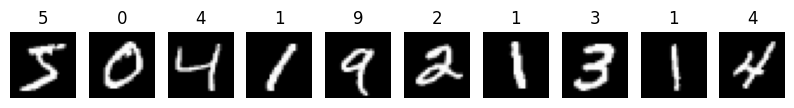

In [6]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.show()

## 4. Build the CNN Model
We define a Sequential CNN architecture consisting of convolutional layers, pooling layers, a flattening step, and fully connected dense layers ending in softmax output.

In [9]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

## 5. Compile and Train the Model
We compile the model with the Adam optimizer and sparse categorical crossentropy loss. The training runs for several epochs with validation accuracy monitored.


In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8957 - loss: 0.3399 - val_accuracy: 0.9807 - val_loss: 0.0708
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9830 - loss: 0.0569 - val_accuracy: 0.9865 - val_loss: 0.0442
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9880 - val_loss: 0.0441
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9908 - val_loss: 0.0378
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9931 - loss: 0.0203 - val_accuracy: 0.9892 - val_loss: 0.0377


## 6. Evaluate the Model
We evaluate the trained model on the test set to measure its performance on unseen data.


In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0471
Test accuracy: 0.9906


## 7. Plot Training History
We plot the training and validation accuracy over epochs to understand how the model learned over time. This helps us detect signs of underfitting or overfitting.


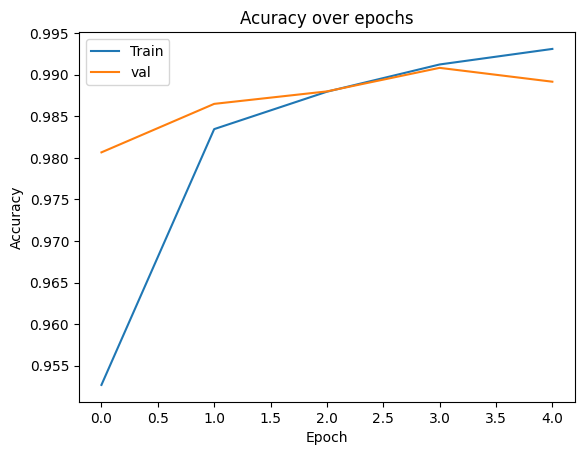

In [15]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Acuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## ✅ Summary
- Learned the structure and components of a basic CNN.
- Built and trained a model to classify handwritten digits.
- Evaluated the model and visualized performance trends over training epochs.